# Grouped summarization in pandas

In [1]:
# initialization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The .groupby() method of pandas DataFrame

Sometimes your data can be partitioned into multiple subsets, and it would be useful to obtain summary statistics on each subset. As an example, we will use the fish length and weight data taken from Alaskan shore between 1997-2006. More information about the source data can be found on [https://lod.bco-dmo.org/id/dataset/3332](https://www.bco-dmo.org/dataset/3332), and the simplified data we use can be found as the csv file [here](https://github.com/OCEAN-215-2026/preclass/tree/main/week_09/data/secm_fish_size.csv).

In [2]:
fish = pd.read_csv("data/secm_fish_size.csv", parse_dates = ["date"])
display(fish)

,date,haul_id,fish_id,species,length,weight
0,1997-05-20,1001,6,Platichthys_stellatus,347.0,500.0
1,1997-05-20,1001,7,Platichthys_stellatus,341.0,430.0
2,1997-05-20,1001,8,Platichthys_stellatus,339.0,459.0
3,1997-05-20,1001,9,Platichthys_stellatus,337.0,398.0
4,1997-05-20,1001,10,Platichthys_stellatus,309.0,325.0
...,...,...,...,...,...,...
1674,2006-07-30,10085,17,Oncorhynchus_tshawytscha,472.0,1375.0
1675,2006-07-31,10088,27,Oncorhynchus_tshawytscha,442.0,1400.0
1676,2006-07-31,10090,34,Oncorhynchus_tshawytscha,563.0,2300.0
1677,2006-07-31,10090,35,Oncorhynchus_tshawytscha,459.0,1150.0


In [3]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     1679 non-null   datetime64[us]
 1   haul_id  1679 non-null   int64         
 2   fish_id  1679 non-null   int64         
 3   species  1679 non-null   str           
 4   length   1679 non-null   float64       
 5   weight   1679 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 78.8 KB


If you inspect the dataset, you will see that many fish species show up many, many times. Given this data, a question one might ask is how the typical length of the fish differs by species.

Conceptually, in order to answer this question, we may loop through the unique species names in the dataset. Then, for each species name we subset the data to only that species and calculate the average length. Finally, we can collect the results into a single dataframe. 


Alternatively, one may think of the calculation as consisting of 3 steps: (1) **split** the dataset by species, (2) **apply** the arithmetic mean on each subset, and (3) **combine** the result. This is illustrated in the figure below:

![An illustration of the split-apply-combine strategy](img/split_apply_combine_length.png)

Conveniently, pandas has a built-in `.groupby()` method to help with this **split-apply-combine** pipeline. The `.groupby()` method will create the split and perform the combination. We just have to supply the function to apply via method chaining. 

In our case, we are interested in the length of fish and we want each group to consist of fish from the same species. So we first subset our data (via `.loc[]`) to include only the "species" and the "length" columns. Then, we supply "species" as the argument to the `.groupby()` method. Finally, the summarization function we want in this case is `.mean()`, which we chain to the end of the group-by. In total, we do: 

In [4]:
fish_grp_mean_len = fish.loc[:, ["species", "length"]].groupby("species").mean()
display(fish_grp_mean_len)

,length
species,
Anarrhichthys_ocellatus,587.000000
Anoplopoma_fimbria,320.172043
Brama_japonica,348.538462
Clupea_pallasi,208.000000
Gadus_macrocephalus,308.700000
Merluccius_productus,492.500000
Oncorhynchus_gorbuscha,498.892000
Oncorhynchus_keta,656.794118
Oncorhynchus_kisutch,596.736842


Notice that the variable used for grouping (`species`) is now the index of the `DataFrame`. Again, we can turn the index back to a regular column using `.reset_index()`

In [5]:
fish_grp_mean_len = fish_grp_mean_len.reset_index()
display(fish_grp_mean_len)

,species,length
0,Anarrhichthys_ocellatus,587.000000
1,Anoplopoma_fimbria,320.172043
2,Brama_japonica,348.538462
3,Clupea_pallasi,208.000000
4,Gadus_macrocephalus,308.700000
5,Merluccius_productus,492.500000
6,Oncorhynchus_gorbuscha,498.892000
7,Oncorhynchus_keta,656.794118
8,Oncorhynchus_kisutch,596.736842
9,Oncorhynchus_nerka,613.909091


Sometimes we may be interested in summarizing more than one column. As long as the summarization function is the same, we can achieve this simply by including all relevant columns in the initial subset. For example, if we are interested in **both** average length **and** average weight, we can do:

In [6]:
fish_grp_mean = fish.loc[:, ["species", "length", "weight"]].groupby("species").mean()
fish_grp_mean = fish_grp_mean.reset_index()
fish_grp_mean

,species,length,weight
0,Anarrhichthys_ocellatus,587.000000,1130.000000
1,Anoplopoma_fimbria,320.172043,386.913978
2,Brama_japonica,348.538462,1057.692308
3,Clupea_pallasi,208.000000,145.000000
4,Gadus_macrocephalus,308.700000,229.000000
5,Merluccius_productus,492.500000,825.000000
6,Oncorhynchus_gorbuscha,498.892000,1595.200000
7,Oncorhynchus_keta,656.794118,3531.323529
8,Oncorhynchus_kisutch,596.736842,3022.421053
9,Oncorhynchus_nerka,613.909091,2913.636364


In addition to grouped mean, the following functions are available for grouped summarization:

+ `.count()`: count the number of non-NA values in each group
+ `.max()`: Compute the maximum value in each group
+ `.min()`: Compute the minimum value in each group
+ `.mean()`: Compute the mean of each group
+ `.median()`: Compute the median of each group
+ `.nunique()`: Compute the number of unique values in each group
+ `.quantile()`: Compute a given quantile of the values in each group
+ `.sem()`: Compute the standard error of the mean of the values in each group
+ `.std()`: Compute the standard deviation of the values in each group
+ `.var()`: Compute the variance of the values in each group

Recall in week 4 we talked about the concept of standard error, which is a measure of the uncertainty in the mean. To compute the standard error, we use the `.sem()` method after the `.groupby()`

In [7]:
fish_grp_sem = fish.loc[
    :, ["species", "length", "weight"]
].groupby("species").sem().reset_index()

display(fish_grp_sem)

,species,length,weight
0,Anarrhichthys_ocellatus,NaN,NaN
1,Anoplopoma_fimbria,5.672692,16.722263
2,Brama_japonica,5.704941,43.796643
3,Clupea_pallasi,NaN,NaN
4,Gadus_macrocephalus,5.166237,16.512621
5,Merluccius_productus,77.500000,225.000000
6,Oncorhynchus_gorbuscha,2.616592,35.521924
7,Oncorhynchus_keta,9.004256,152.740822
8,Oncorhynchus_kisutch,13.860012,158.806295
9,Oncorhynchus_nerka,29.958291,315.514796


Note that we have a bunch of `NaN`s in the results, which is a consequence of the fact that some species appeared only once in the dataset.

To combine the summary of averages with the summary of uncertainties in the averages, we can use `pd.concat()` on the two DataFrames, setting the optional argument `axis=1`. 

Because some column names in the two DataFrames are repeated, we first have to modify those names:

In [8]:
fish_grp_mean.columns = ["species", "mean_length", "mean_weight"]
fish_grp_sem.columns = ["species", "stderr_length", "stderr_weight"]

Now we can combine the two DataFrames into one. To make the two DataFrames align, we set the indices of both DataFrames to "species", which we reset at the end of the process. In all, we do:

In [9]:
fish_grp_stats = pd.concat([
    fish_grp_mean.set_index("species"), 
    fish_grp_sem.set_index("species")
], axis = 1).reset_index()

display(fish_grp_stats)

,species,mean_length,mean_weight,stderr_length,stderr_weight
0,Anarrhichthys_ocellatus,587.000000,1130.000000,NaN,NaN
1,Anoplopoma_fimbria,320.172043,386.913978,5.672692,16.722263
2,Brama_japonica,348.538462,1057.692308,5.704941,43.796643
3,Clupea_pallasi,208.000000,145.000000,NaN,NaN
4,Gadus_macrocephalus,308.700000,229.000000,5.166237,16.512621
5,Merluccius_productus,492.500000,825.000000,77.500000,225.000000
6,Oncorhynchus_gorbuscha,498.892000,1595.200000,2.616592,35.521924
7,Oncorhynchus_keta,656.794118,3531.323529,9.004256,152.740822
8,Oncorhynchus_kisutch,596.736842,3022.421053,13.860012,158.806295
9,Oncorhynchus_nerka,613.909091,2913.636364,29.958291,315.514796


## Example: climatology

As a second example, suppose we are interested in climatology, i.e., the long term weather pattern. Our source data are weather information at the SeaTac airport and Spokane airport, from 2020 to 2024. The data is sourced from [NOAA Climate Data Online](https://www.ncei.noaa.gov/cdo-web/), and a copy of the simplified and combined data we use can be found [here](https://github.com/OCEAN-215-2026/preclass/tree/main/week_09/data/WA_weather_2000-2024.csv).

In [10]:
WA_weather = pd.read_csv("data/WA_weather_2000-2024.csv", parse_dates = ["DATE"])
display(WA_weather)

,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,TAVG,TMAX,TMIN
0,"SEATTLE TACOMA AIRPORT, WA US",47.44467,-122.31442,112.5,2000-01-01,6.9,4.4,6.1,2.8
1,"SEATTLE TACOMA AIRPORT, WA US",47.44467,-122.31442,112.5,2000-01-02,0.0,-3.9,7.2,2.8
2,"SEATTLE TACOMA AIRPORT, WA US",47.44467,-122.31442,112.5,2000-01-03,7.1,5.6,8.3,2.2
3,"SEATTLE TACOMA AIRPORT, WA US",47.44467,-122.31442,112.5,2000-01-04,7.6,7.8,10.0,5.6
4,"SEATTLE TACOMA AIRPORT, WA US",47.44467,-122.31442,112.5,2000-01-05,0.0,5.0,6.7,2.8
...,...,...,...,...,...,...,...,...,...
18259,"SPOKANE INTERNATIONAL AIRPORT, WA US",47.62168,-117.52796,717.7,2024-12-27,0.8,2.7,4.4,0.6
18260,"SPOKANE INTERNATIONAL AIRPORT, WA US",47.62168,-117.52796,717.7,2024-12-28,4.3,4.4,7.2,3.3
18261,"SPOKANE INTERNATIONAL AIRPORT, WA US",47.62168,-117.52796,717.7,2024-12-29,15.2,3.7,3.9,0.6
18262,"SPOKANE INTERNATIONAL AIRPORT, WA US",47.62168,-117.52796,717.7,2024-12-30,8.9,1.1,2.8,-1.6


In [11]:
WA_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 18264 entries, 0 to 18263
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   NAME       18264 non-null  str           
 1   LATITUDE   18264 non-null  float64       
 2   LONGITUDE  18264 non-null  float64       
 3   ELEVATION  18264 non-null  float64       
 4   DATE       18264 non-null  datetime64[us]
 5   PRCP       18259 non-null  float64       
 6   TAVG       12654 non-null  float64       
 7   TMAX       18264 non-null  float64       
 8   TMIN       18263 non-null  float64       
dtypes: datetime64[us](1), float64(7), str(1)
memory usage: 1.3 MB


We are interested in analyzing the numeric variables `PRCP`, `TAVG`, `TMAX`, and `TMIN` for each day of the year and for each location. To proceed, we first generate a `day_of_year` column:

In [12]:
WA_weather["day_of_year"] = WA_weather["DATE"].dt.dayofyear

Next, noting that our group-by variables are `NAME` and `day_of_year` and our variables to summarize are `PRCP`, `TAVG`, `TMAX`, and `TMIN`, we can subset the dataset like so: 

In [13]:
WA_weather_sub = WA_weather.loc[:, ["NAME", "day_of_year", "PRCP", "TAVG", "TMAX", "TMIN"]]

Now we can perform the split-apply-combine procedure for the mean and the standard error. Because we want to consider each day of the year **and** each location, we need to group by both `NAME` and `day_of_year`:

In [14]:
WA_weather_mean = WA_weather_sub.groupby(
    ["NAME", "day_of_year"]
).mean().reset_index()

WA_weather_sem = WA_weather_sub.groupby(
    ["NAME", "day_of_year"]
).sem().reset_index()

In [15]:
WA_weather_mean

,NAME,day_of_year,PRCP,TAVG,TMAX,TMIN
0,"SEATTLE TACOMA AIRPORT, WA US",1,4.688000,4.276471,7.736000,1.844000
1,"SEATTLE TACOMA AIRPORT, WA US",2,7.264000,4.029412,7.820000,1.928000
2,"SEATTLE TACOMA AIRPORT, WA US",3,4.600000,4.988235,8.104000,2.112000
3,"SEATTLE TACOMA AIRPORT, WA US",4,5.864000,5.229412,7.980000,2.720000
4,"SEATTLE TACOMA AIRPORT, WA US",5,5.540000,5.147059,8.076000,3.072000
...,...,...,...,...,...,...
727,"SPOKANE INTERNATIONAL AIRPORT, WA US",362,2.372000,-2.082353,0.684000,-3.824000
728,"SPOKANE INTERNATIONAL AIRPORT, WA US",363,2.172000,-2.535294,0.744000,-4.868000
729,"SPOKANE INTERNATIONAL AIRPORT, WA US",364,2.672000,-2.600000,-0.364000,-5.756000
730,"SPOKANE INTERNATIONAL AIRPORT, WA US",365,2.464000,-2.952941,-0.756000,-6.404000


Finally, let's combine the averages and the uncertainties in averages into a single table:

In [16]:
WA_weather_mean.columns = [
    "NAME", "day_of_year", "PRCP_mean", "TAVG_mean", "TMAX_mean", "TMIN_mean"
]

WA_weather_sem.columns = [
    "NAME", "day_of_year", "PRCP_sem", "TAVG_sem", "TMAX_sem", "TMIN_sem"
]

WA_weather_stat = pd.concat([
    WA_weather_mean.set_index(["NAME", "day_of_year"]),
    WA_weather_sem.set_index(["NAME", "day_of_year"])
], axis = 1).reset_index() 

display(WA_weather_stat)

,NAME,day_of_year,PRCP_mean,TAVG_mean,TMAX_mean,TMIN_mean,PRCP_sem,TAVG_sem,TMAX_sem,TMIN_sem
0,"SEATTLE TACOMA AIRPORT, WA US",1,4.688000,4.276471,7.736000,1.844000,1.379690,0.843423,0.635082,0.761732
1,"SEATTLE TACOMA AIRPORT, WA US",2,7.264000,4.029412,7.820000,1.928000,2.506318,0.945335,0.659722,0.685845
2,"SEATTLE TACOMA AIRPORT, WA US",3,4.600000,4.988235,8.104000,2.112000,1.353255,0.837006,0.721376,0.732719
3,"SEATTLE TACOMA AIRPORT, WA US",4,5.864000,5.229412,7.980000,2.720000,1.405938,1.042895,0.787274,0.800854
4,"SEATTLE TACOMA AIRPORT, WA US",5,5.540000,5.147059,8.076000,3.072000,1.581086,1.052522,0.750628,0.855015
...,...,...,...,...,...,...,...,...,...,...
727,"SPOKANE INTERNATIONAL AIRPORT, WA US",362,2.372000,-2.082353,0.684000,-3.824000,0.652394,0.866460,0.768346,0.818235
728,"SPOKANE INTERNATIONAL AIRPORT, WA US",363,2.172000,-2.535294,0.744000,-4.868000,0.935566,0.942460,0.770348,0.887087
729,"SPOKANE INTERNATIONAL AIRPORT, WA US",364,2.672000,-2.600000,-0.364000,-5.756000,0.914577,1.119381,0.786318,0.953748
730,"SPOKANE INTERNATIONAL AIRPORT, WA US",365,2.464000,-2.952941,-0.756000,-6.404000,0.981884,0.988579,0.826803,1.228257


Now that we have obtained the climatology data, let's visualize the climatology of the average temperature with a plot. To do so, we need to split the DataFrame above into two data series, one for SeaTac airport and one for Spokane:

In [17]:
spokane_stat = WA_weather_stat.loc[WA_weather_stat["NAME"] == "SPOKANE INTERNATIONAL AIRPORT, WA US"]
seatac_stat = WA_weather_stat.loc[WA_weather_stat["NAME"] == "SEATTLE TACOMA AIRPORT, WA US"]

With the two locations separated out we can now plot:

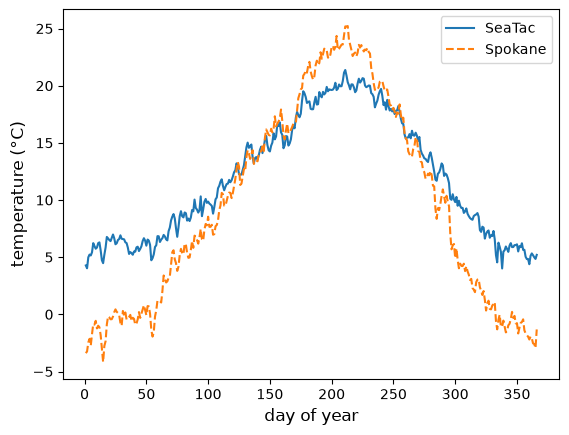

In [18]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(seatac_stat["day_of_year"], seatac_stat["TAVG_mean"], ls = "-", label="SeaTac")
ax.plot(spokane_stat["day_of_year"], spokane_stat["TAVG_mean"], ls = "--", label="Spokane")

ax.set_xlabel("day of year", fontsize=12)
ax.set_ylabel("temperature (°C)", fontsize=12)

ax.legend()

plt.show(fig)

We observe that Spokane has a larger range of temperature variation over the course of a year than SeaTac, most likely because it is more inland than SeaTac.